## 4. Correlation

In [4]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf

In [5]:
# Load the dataset
# df = pd.read_csv("Data\winequality-red.csv")
df = pd.read_csv("TrainingDataStand.csv")

In [6]:
X_scaled = df.drop(columns=["steerAngle"])

In [12]:
from sklearn.decomposition import PCA
feature_names = X_scaled.columns

# Apply PCA
pca = PCA(n_components=len(feature_names))  # Keep all components
X_pca = pca.fit_transform(X_scaled)

# Compute feature importance based on absolute component weights
nPC_selected = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1  # Select PCs covering 90% variance

# Compute feature importance
pca_components = np.abs(pca.components_[:nPC_selected, :])  # Take absolute values
feature_importance = np.sum(pca_components, axis=0)  # Sum contributions across top PCs

# Select top features based on importance
num_selected_features = 5  # Choose the top 5 most important features
selected_feature_indices = np.argsort(-feature_importance)[:num_selected_features]
selected_features = feature_names[selected_feature_indices]

# Print selected features
print("Selected Features (PFA):", list(selected_features))

Selected Features (PFA): ['dHE', 'CTE', 'HeadingError', 'curvature', 'lookAhead1']


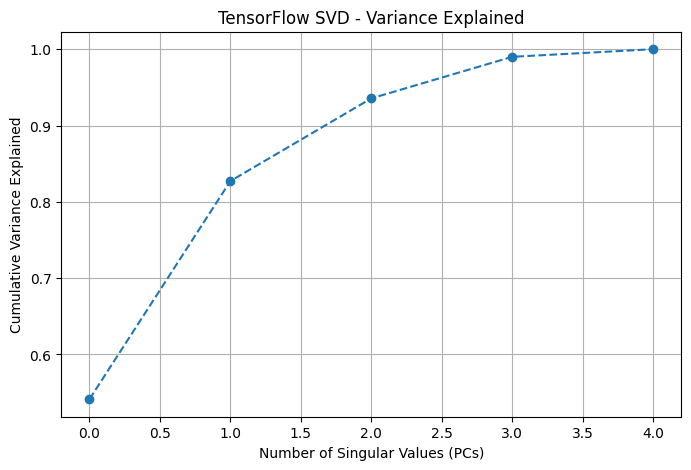

In [7]:
# Convert data to TensorFlow tensor
X_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)

# Compute SVD (PCA-like transformation)
s, u, v = tf.linalg.svd(X_tf)

# Compute explained variance (equivalent to PCA)
explained_variance_tf = (s ** 2) / tf.reduce_sum(s ** 2)

# Convert to NumPy for analysis
explained_variance_np = explained_variance_tf.numpy()

# Plot TensorFlow SVD-based PCA results
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance_np), marker='o', linestyle='--')
plt.xlabel("Number of Singular Values (PCs)")
plt.ylabel("Cumulative Variance Explained")
plt.title("TensorFlow SVD - Variance Explained")
plt.grid(True)
plt.show()


Produce a heatmap based on the correlation matrix, displaying the Pearson Correlation Coefficient (r).

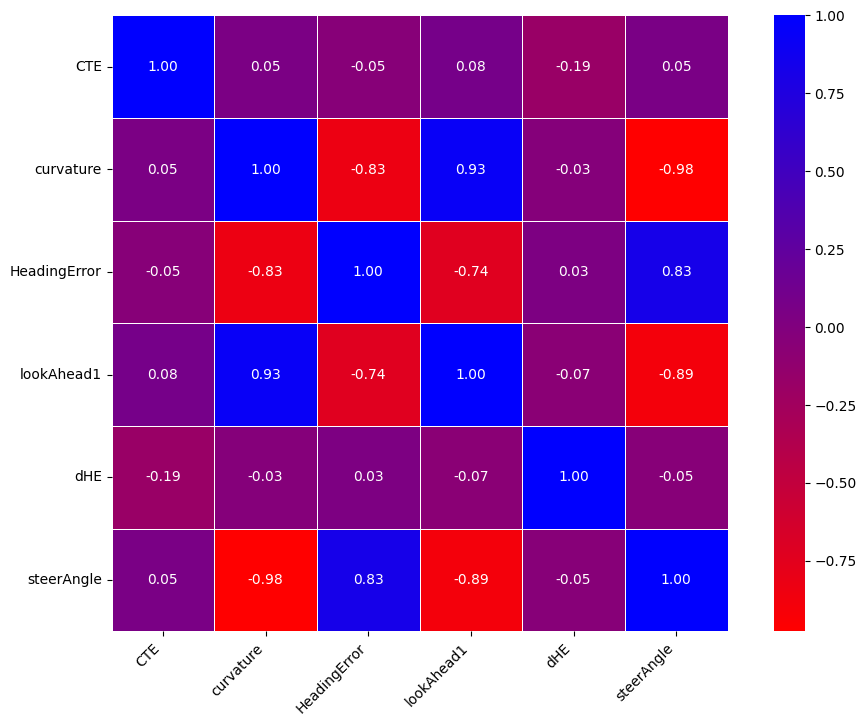

In [3]:
# Compute the correlation matrix
correlation_matrix = df.corr()

from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("RedPurpleBlue", ["red", "purple", "blue"])

# Plot the correlation matrix as a heatmap with numbers
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap=cmap, linewidths=0.5, square=True, cbar=True)

# Title and layout adjustments
# plt.title("Correlation Matrix Heatmap", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Show the heatmap
plt.show()

Plot scatters of Alcohol, Volatile Acidity & Residual Sugar against Quality.

Text(0.5, 1.0, 'Residual Sugar vs. Quality')

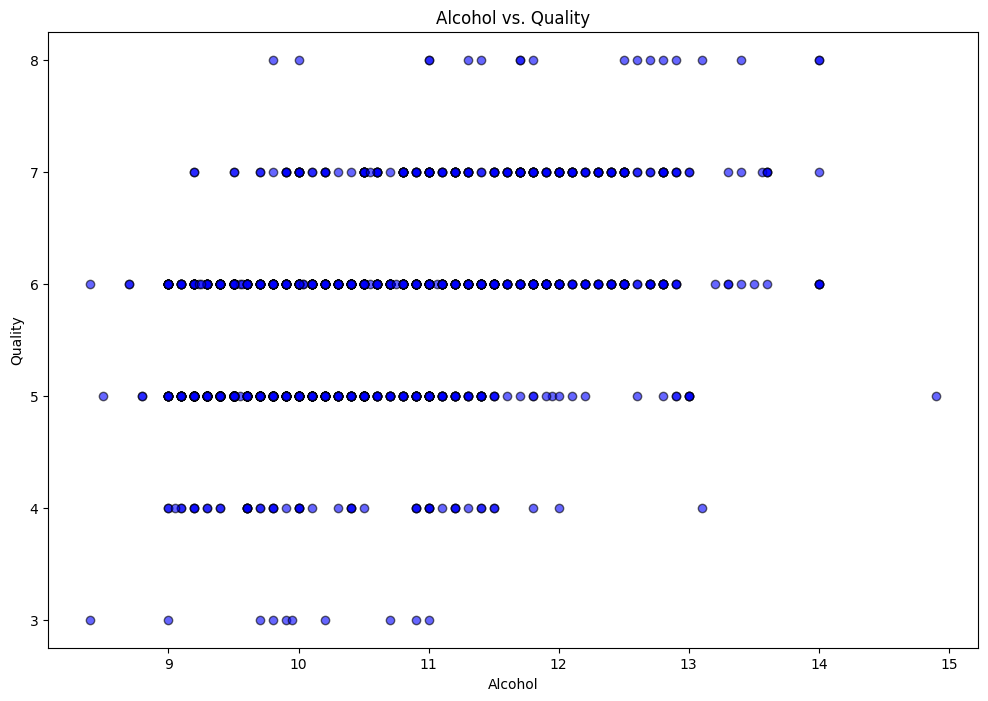

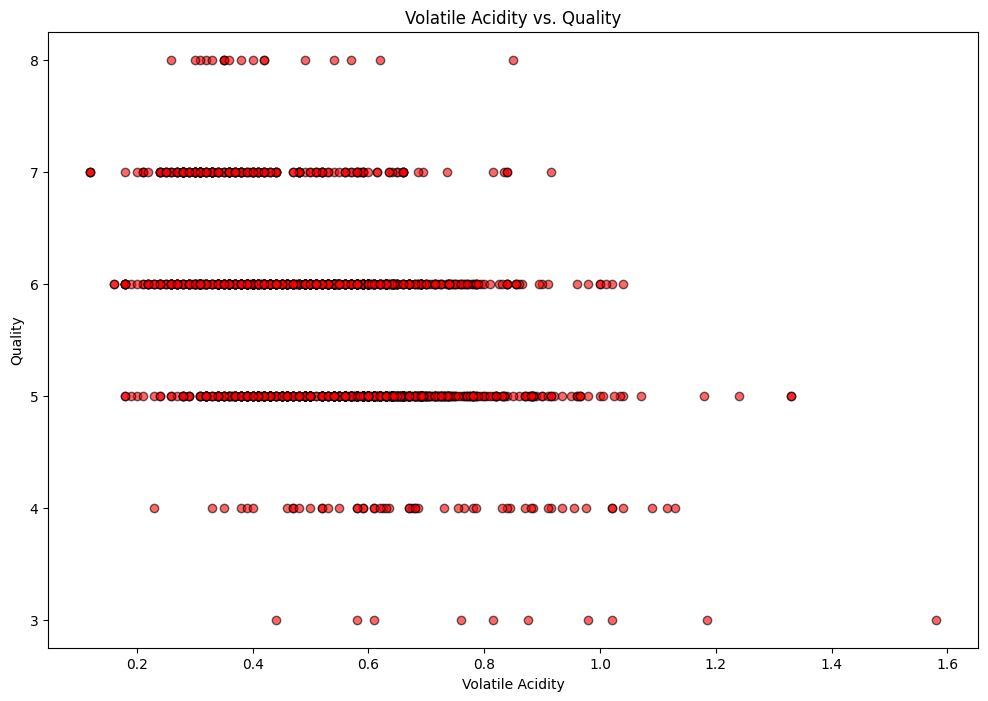

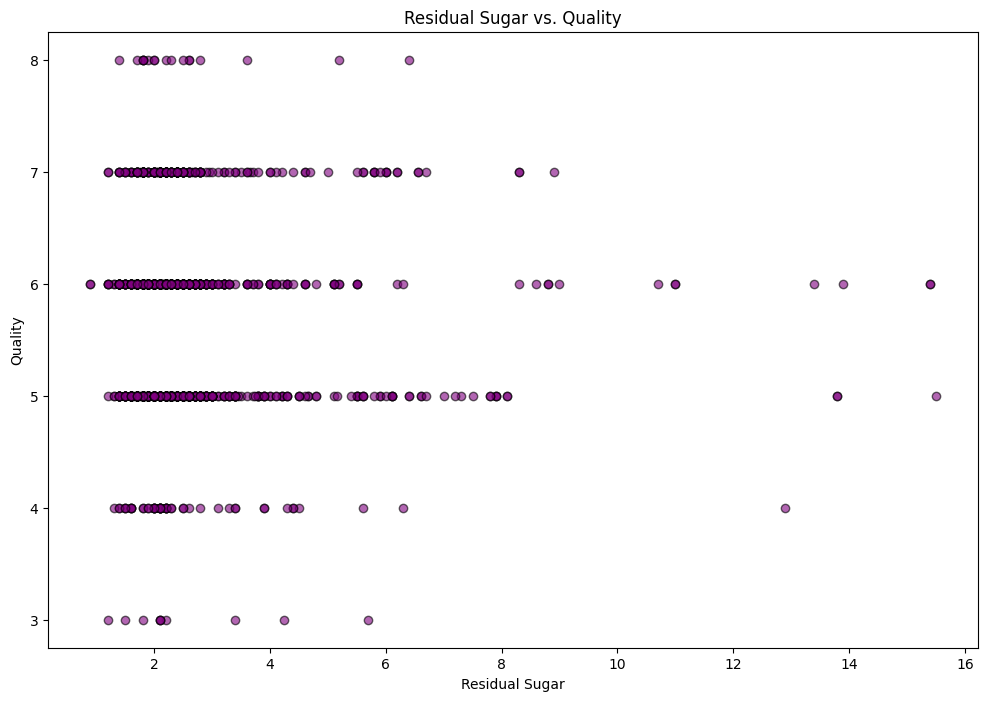

In [20]:
# Plot scatters - individually

# Scatter plot 1
plt.figure(figsize=(12, 8))
plt.scatter(df['alcohol'], df['quality'], alpha=0.6, color="blue", edgecolors="black")
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Alcohol vs. Quality")

# Scatter plot 2
plt.figure(figsize=(12, 8))
plt.scatter(df['volatile acidity'], df['quality'], alpha=0.6, color="red", edgecolors="black")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")
plt.title("Volatile Acidity vs. Quality")

# Scatter plot 3
plt.figure(figsize=(12, 8))
plt.scatter(df['residual sugar'], df['quality'], alpha=0.6, color="purple", edgecolors="black")
plt.xlabel("Residual Sugar")
plt.ylabel("Quality")
plt.title("Residual Sugar vs. Quality")

